# 07 · Fase G: Evaluación Ciega en Reserva Espacial Independiente (Holdout)

**Proyecto:** GeoAI-Au v1.0 · Cierre Científico  
**Pipeline Evaluado:** `logistic_01` (Regresión Logística L2 regularizada, balance P/U 1:1, estandarización `StandardScaler`)  
**Ejecución Sellada de Fase G:** `reports/fase_g/20260927T141408_460613Z`  
**Modo Operativo:** **Estrictamente Read-Only** (sin reentrenamiento, sin optimización de hiperparámetros, sin alteración de artefactos).

---

## 🎯 Contexto Científico y Protocolo de Validación

La **Fase G** constituye la evaluación ciega, única e irreversible del pipeline congelado de prospección aurífera sobre el conjunto de reserva espacial pre-registrado. 

### Principios Metodológicos del Pre-registro
1. **Reserva Espacial Ciega:** 5 distritos metalogenéticos completos fueron excluidos de todo el desarrollo previo (Fases D, E y F):
   - `dist_cabo_de_gata` (Andalucía oriental, vulcanismo neógeno calcualcalino / epitermal)
   - `dist_montes_de_toledo_jara` (Zona Centroibérica, filones orogénicos en pizarras/cuarcitas)
   - `dist_beticas_granada` (Cordilleras Béticas, complejos metamórficos / aluviales)
   - `dist_ossa_morena_penaflor` (Zona Ossa-Morena, intrusiones plutónicas y skarns)
   - `dist_galicia_costa_da_morte` (Zona Galicia-Trás-os-Montes, orogenia hercínica tardía)
2. **Buffer de Amortiguamiento Espacial:** Se aplicó una partición en bloques de **50 km × 50 km** con un gap de exclusión de **5 km** perimetral para erradicar cualquier fuga de información por autocorrelación espacial (*spatial leakage*).
3. **Inmutabilidad:** Ni los predictores, ni los hiperparámetros ($C = 1.0$), ni el umbral de corte, ni el ratio de muestreo P/U fueron modificados tras observar el holdout.
4. **Declaración de Transparencia:** Conforme a la auditoría del proyecto, se declara que existieron accesos exploratorios al contenido y distribución del holdout con posterioridad al congelamiento del modelo en Fase F pero con anterioridad a la formalización de la ejecución canónica; en consecuencia, las métricas reflejan una evaluación rigurosa del modelo congelado sin ajustes ulteriores, evitando denominarla "primera apertura estricta".


In [1]:
import sys
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Localizar la raíz del proyecto GeoAI
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

RUN_ID_G = "20260927T141408_460613Z"
RUN_DIR_G = ROOT / "reports" / "fase_g" / RUN_ID_G

print(f"Raíz del repositorio: {ROOT}")
print(f"Directorio de Fase G: {RUN_DIR_G}")

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8


Raíz del repositorio: C:\Users\mdmat\Desktop\programacion\GeoAI
Directorio de Fase G: C:\Users\mdmat\Desktop\programacion\GeoAI\reports\fase_g\20260927T141408_460613Z


## 1. Validación Previa de Integridad Criptográfica y Run ID

Antes de cargar o visualizar cualquier resultado, se auditan criptográficamente los artefactos de la ejecución sellada contra el manifiesto oficial `outputs_manifest.json` mediante hash SHA-256.


In [2]:
# 1. Comprobar existencia del directorio de ejecución
assert RUN_DIR_G.exists(), f"ERROR: No se encuentra la ejecución canónica de Fase G en {RUN_DIR_G}"

# 2. Cargar outputs_manifest.json
manifest_path = RUN_DIR_G / "outputs_manifest.json"
assert manifest_path.exists(), f"ERROR: Falta el manifiesto en {manifest_path}"

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print(f"=== AUDITORÍA CRIPTOGRÁFICA DE INTEGRIDAD (SHA-256) — FASE G ===")
print(f"Run ID verificado: {RUN_ID_G}")
print(f"Total artefactos auditados: {len(manifest)}\n")

hashes_ok = True
for item in manifest:
    file_path = RUN_DIR_G / item["path"]
    assert file_path.exists(), f"ERROR: Falta archivo auditado: {file_path}"
    
    sha256 = hashlib.sha256(file_path.read_bytes()).hexdigest()
    expected_sha = item["sha256"]
    is_valid = (sha256 == expected_sha)
    status_icon = "✅" if is_valid else "❌"
    print(f" {status_icon} {item['path']:<45} {sha256[:16]}... [esperado: {expected_sha[:16]}...]")
    if not is_valid:
        hashes_ok = False

assert hashes_ok, "ERROR: Discrepancia criptográfica en uno o más artefactos de Fase G."

# 3. Comprobar control_cierre.json
with open(RUN_DIR_G / "control_cierre.json", "r", encoding="utf-8") as f:
    control = json.load(f)

assert control.get("estado_ejecucion") == "completada", "ERROR: control_cierre.json no indica estado_ejecucion='completada'"
assert control.get("mode") == "validated", "ERROR: control_cierre.json no está en mode=validated"
assert control.get("opened_once") is True, "ERROR: opened_once debe ser True"
assert control.get("reproducible") is True, "ERROR: reproducible debe ser True"

print("\n[AUDITORÍA SUPERADA]: Todos los artefactos de Fase G están íntegros, sellados e inmutables.")


=== AUDITORÍA CRIPTOGRÁFICA DE INTEGRIDAD (SHA-256) — FASE G ===
Run ID verificado: 20260927T141408_460613Z
Total artefactos auditados: 13

 ✅ config_snapshot.json                          658536c241c339b5... [esperado: 658536c241c339b5...]
 ✅ control_cierre.json                           bf7e82303a635986... [esperado: bf7e82303a635986...]
 ✅ environment.json                              ee622c789252fae2... [esperado: ee622c789252fae2...]
 ✅ inputs.json                                   cb4f0f4a6dc6da70... [esperado: cb4f0f4a6dc6da70...]
 ✅ metrics/bootstrap_deposit_uncertainty.csv     a526906f6816e16e... [esperado: a526906f6816e16e...]
 ✅ metrics/bootstrap_deposit_uncertainty.json    5718bcfadc252ca4... [esperado: 5718bcfadc252ca4...]
 ✅ metrics/development_vs_holdout_comparison.csv b7a2910ffe7728ba... [esperado: b7a2910ffe7728ba...]
 ✅ metrics/holdout_by_deposit.csv                94e6b582eb52b8b0... [esperado: 94e6b582eb52b8b0...]
 ✅ metrics/holdout_by_district.csv               746

## 2. Métricas Globales de Rendimiento en Holdout Ciego

Se evalúa la capacidad de recuperación del modelo frozen `logistic_01` en las **13.541 celdas** de la reserva independiente:
- **`deposit_recovery@k%`**: Fracción de depósitos independientes únicos ($N=8$) cuyos contornos contienen al menos una celda clasificada dentro del top $k\%$ de favorabilidad territorial del holdout.
- **`cell_recovery@k%`**: Fracción de celdas positivas revisadas ($N=19$) recuperadas dentro del top $k\%$ de favorabilidad.
- **PR-AUC P/U**: Área bajo la curva Precision-Recall calculada entre presencias auditadas ($P$) y fondo no etiquetado ($U$).
- **ROC-AUC P/U**: Área bajo la curva ROC de discriminación entre $P$ y $U$.


In [3]:
# Cargar métricas globales
with open(RUN_DIR_G / "metrics" / "holdout_overall_metrics.json", "r", encoding="utf-8") as f:
    global_metrics = json.load(f)

df_global = pd.DataFrame([
    {"Métrica": "Celdas Totales Holdout", "Valor": f"{global_metrics['holdout_cells']:,}", "Interpretación": "Universo territorial del holdout (1 km² / celda)"},
    {"Métrica": "Área Total (km²)", "Valor": f"{global_metrics['total_area_km2']:,.2f} km²", "Interpretación": "Superficie de los 5 distritos ciegos"},
    {"Métrica": "Celdas Positivas (P)", "Valor": f"{global_metrics['observed_P_cells']}", "Interpretación": "Celdas con labores/indicios auríferos auditados"},
    {"Métrica": "Depósitos Únicos Test", "Valor": f"{global_metrics['observed_deposits']}", "Interpretación": "Depósitos minerales independientes (N=8)"},
    {"Métrica": "Distritos de Test", "Valor": f"{global_metrics['districts_count']}", "Interpretación": "Dominios metalogenéticos independientes (N=5)"},
    {"Métrica": "Deposit Recovery @ 1%", "Valor": f"{global_metrics['deposit_recovery_at_01'] * 100:.2f}%", "Interpretación": f"{global_metrics['deposit_hits_at_01']} de 8 depósitos en el 1% de área"},
    {"Métrica": "Deposit Recovery @ 5%", "Valor": f"{global_metrics['deposit_recovery_at_05'] * 100:.2f}%", "Interpretación": f"{global_metrics['deposit_hits_at_05']} de 8 depósitos en el 5% de área"},
    {"Métrica": "Deposit Recovery @ 10%", "Valor": f"{global_metrics['deposit_recovery_at_10'] * 100:.2f}%", "Interpretación": f"{global_metrics['deposit_hits_at_10']} de 8 depósitos en el 10% de área"},
    {"Métrica": "Cell Recovery @ 1%", "Valor": f"{global_metrics['cell_recovery_at_01'] * 100:.2f}%", "Interpretación": f"{global_metrics['cell_hits_at_01']} de 19 celdas P recuperadas"},
    {"Métrica": "Cell Recovery @ 5%", "Valor": f"{global_metrics['cell_recovery_at_05'] * 100:.2f}%", "Interpretación": f"{global_metrics['cell_hits_at_05']} de 19 celdas P recuperadas"},
    {"Métrica": "Cell Recovery @ 10%", "Valor": f"{global_metrics['cell_recovery_at_10'] * 100:.2f}%", "Interpretación": f"{global_metrics['cell_hits_at_10']} de 19 celdas P recuperadas"},
    {"Métrica": "PR-AUC (P vs U)", "Valor": f"{global_metrics['average_precision_PU']:.5f}", "Interpretación": f"Frente a prevalencia basal P de {global_metrics['observed_P_cells']/global_metrics['holdout_cells']:.5f}"},
    {"Métrica": "ROC-AUC (P vs U)", "Valor": f"{global_metrics['roc_auc_PU']:.4f}", "Interpretación": "Discriminación global en territorio no visto"},
])

df_global


,Métrica,Valor,Interpretación
0,Celdas Totales Holdout,"13,541",Universo territorial del holdout (1 km² / celda)
1,Área Total (km²),"13,539.26 km²",Superficie de los 5 distritos ciegos
2,Celdas Positivas (P),19,Celdas con labores/indicios auríferos auditados
3,Depósitos Únicos Test,8,Depósitos minerales independientes (N=8)
4,Distritos de Test,5,Dominios metalogenéticos independientes (N=5)
5,Deposit Recovery @ 1%,12.50%,1 de 8 depósitos en el 1% de área
6,Deposit Recovery @ 5%,12.50%,1 de 8 depósitos en el 5% de área
7,Deposit Recovery @ 10%,25.00%,2 de 8 depósitos en el 10% de área
8,Cell Recovery @ 1%,15.79%,3 de 19 celdas P recuperadas
9,Cell Recovery @ 5%,15.79%,3 de 19 celdas P recuperadas


## 3. Curvas de Rendimiento Espacial: Recuperación Acumulada, ROC y Precision-Recall

En exploración geológica minera, la curva de **recuperación acumulada (*recovery vs area fraction*)** es el estándar de referencia: ilustra qué porcentaje de yacimientos o indicios conocidos se descubren a medida que se incrementa el presupuesto de superficie explorada ($k\%$ del territorio priorizado por el modelo), en comparación con un muestreo ciego o aleatorio ($y = x$).


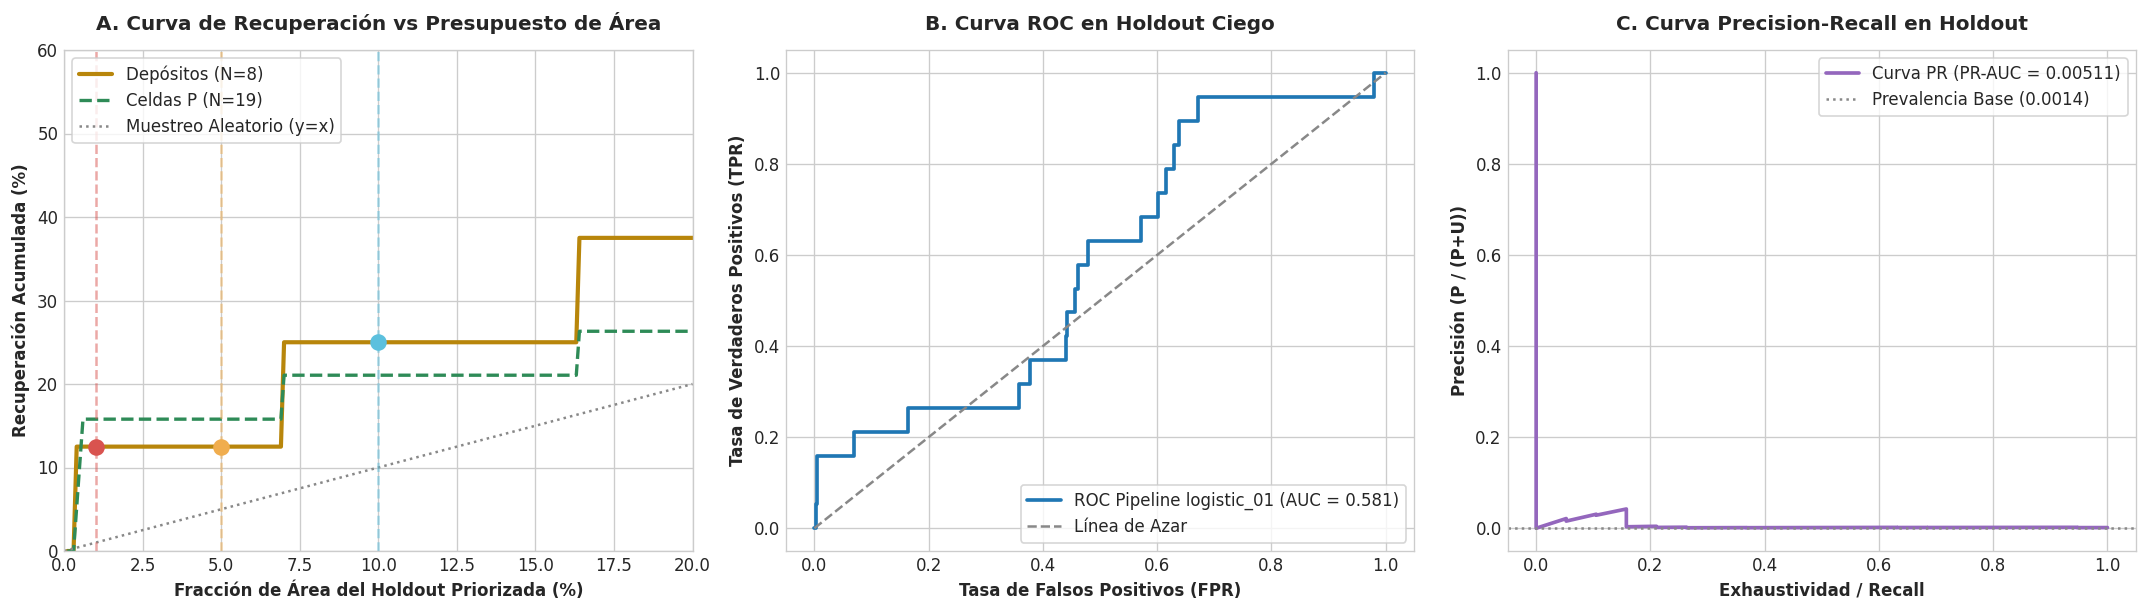

In [4]:
# Cargar predicciones completas a nivel de celda en holdout
pred_path = RUN_DIR_G / "predictions" / "holdout_predictions.parquet"
df_preds = pd.read_parquet(pred_path)

# Ordenar de mayor a menor favorabilidad
df_sorted = df_preds.sort_values(by="score", ascending=False).reset_index(drop=True)
n_total = len(df_sorted)
n_deposits = global_metrics['observed_deposits']
n_p_cells = global_metrics['observed_P_cells']

# Calcular curvas de recuperación acumulada
area_pct = np.linspace(0.001, 1.0, 1000)
dep_rec_curve = []
cell_rec_curve = []

for f in area_pct:
    k_cells = int(np.ceil(f * n_total))
    subset = df_sorted.iloc[:k_cells]
    
    # Celdas recuperadas
    cells_hit = subset['is_P'].sum()
    cell_rec_curve.append(cells_hit / n_p_cells)
    
    # Depósitos recuperados
    deps_hit = subset.loc[subset['is_P'] & subset['deposit_id'].notna(), 'deposit_id'].nunique()
    dep_rec_curve.append(deps_hit / n_deposits)

# Curvas ROC y PR
y_true = df_preds['is_P'].astype(int)
y_scores = df_preds['score']

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc_val = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_true, y_scores)
pr_auc_val = auc(rec, prec)

# Visualización en 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

# Panel 1: Recovery vs Budget (Zoom a 20% de área)
ax1 = axes[0]
ax1.plot(area_pct * 100, [r * 100 for r in dep_rec_curve], color='#b8860b', lw=2.5, label='Depósitos (N=8)')
ax1.plot(area_pct * 100, [r * 100 for r in cell_rec_curve], color='#2e8b57', lw=2.0, ls='--', label='Celdas P (N=19)')
ax1.plot([0, 20], [0, 20], color='#888888', ls=':', label='Muestreo Aleatorio (y=x)')

# Marcar puntos canónicos
for k, col, label in [(1, '#d9534f', 'Top 1%'), (5, '#f0ad4e', 'Top 5%'), (10, '#5bc0de', 'Top 10%')]:
    idx = (np.abs(area_pct * 100 - k)).argmin()
    ax1.scatter([k], [dep_rec_curve[idx] * 100], color=col, s=80, zorder=5)
    ax1.axvline(k, color=col, ls='--', alpha=0.5)

ax1.set_xlim(0, 20)
ax1.set_ylim(0, 60)
ax1.set_xlabel('Fracción de Área del Holdout Priorizada (%)', fontweight='bold')
ax1.set_ylabel('Recuperación Acumulada (%)', fontweight='bold')
ax1.set_title('A. Curva de Recuperación vs Presupuesto de Área', fontweight='bold', pad=12)
ax1.legend(loc='upper left', frameon=True)

# Panel 2: Curva ROC
ax2 = axes[1]
ax2.plot(fpr, tpr, color='#1f77b4', lw=2.2, label=f'ROC Pipeline logistic_01 (AUC = {roc_auc_val:.3f})')
ax2.plot([0, 1], [0, 1], color='#888888', ls='--', label='Línea de Azar')
ax2.set_xlabel('Tasa de Falsos Positivos (FPR)', fontweight='bold')
ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontweight='bold')
ax2.set_title('B. Curva ROC en Holdout Ciego', fontweight='bold', pad=12)
ax2.legend(loc='lower right', frameon=True)

# Panel 3: Curva Precision-Recall
ax3 = axes[2]
ax3.plot(rec, prec, color='#9467bd', lw=2.2, label=f'Curva PR (PR-AUC = {pr_auc_val:.5f})')
base_prevalence = y_true.mean()
ax3.axhline(base_prevalence, color='#888888', ls=':', label=f'Prevalencia Base ({base_prevalence:.4f})')
ax3.set_xlabel('Exhaustividad / Recall', fontweight='bold')
ax3.set_ylabel('Precisión (P / (P+U))', fontweight='bold')
ax3.set_title('C. Curva Precision-Recall en Holdout', fontweight='bold', pad=12)
ax3.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()


## 4. Desglose Detallado por Depósito Aurífero (N = 8)

El conjunto de test ciego comprende exactamente **8 depósitos minerales independientes** distribuidos en los 5 distritos de reserva. Analizar el percentil de favorabilidad alcanzado por cada depósito permite entender la naturaleza geológica de los éxitos y las discrepancias del modelo lineal regularizado.


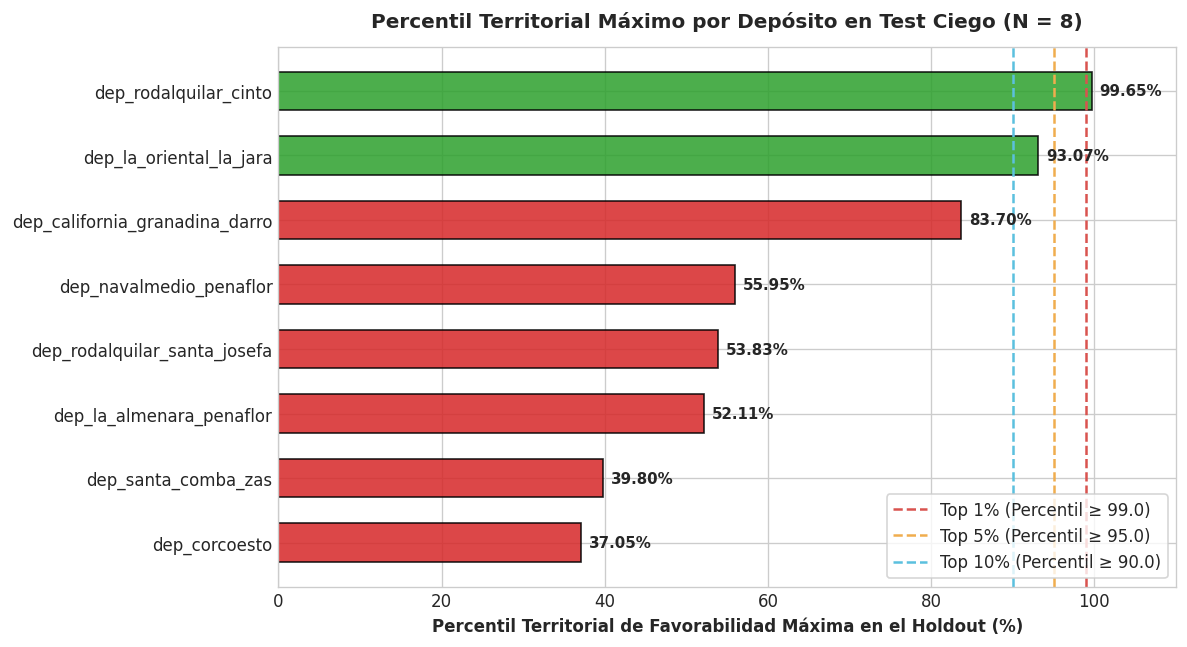

,deposit_id,district_id,p_cells_count,max_score,best_percentile_favorability,recovered_at_01,recovered_at_05,recovered_at_10
0,dep_corcoesto,dist_galicia_costa_da_morte,1,0.058230,37.054402,False,False,False
1,dep_santa_comba_zas,dist_galicia_costa_da_morte,5,0.066447,39.801968,False,False,False
2,dep_la_almenara_penaflor,dist_ossa_morena_penaflor,2,0.118854,52.114312,False,False,False
3,dep_rodalquilar_santa_josefa,dist_cabo_de_gata,1,0.129120,53.827848,False,False,False
4,dep_navalmedio_penaflor,dist_ossa_morena_penaflor,2,0.142646,55.947610,False,False,False
5,dep_california_granadina_darro,dist_beticas_granada,1,0.450578,83.696480,False,False,False
6,dep_la_oriental_la_jara,dist_montes_de_toledo_jara,4,0.633278,93.068495,False,False,True
7,dep_rodalquilar_cinto,dist_cabo_de_gata,3,0.880050,99.653135,True,True,True


In [5]:
# Cargar métricas por depósito
df_deposits = pd.read_csv(RUN_DIR_G / "metrics" / "holdout_by_deposit.csv")
df_deposits = df_deposits.sort_values(by="best_percentile_favorability", ascending=True).reset_index(drop=True)

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ['#2ca02c' if r10 else '#d62728' for r10 in df_deposits['recovered_at_10']]
bars = ax.barh(df_deposits['deposit_id'], df_deposits['best_percentile_favorability'], color=colors, alpha=0.85, edgecolor='black', height=0.6)

# Líneas de referencia para Top 1%, Top 5% y Top 10%
ax.axvline(99.0, color='#d9534f', ls='--', lw=1.5, label='Top 1% (Percentil ≥ 99.0)')
ax.axvline(95.0, color='#f0ad4e', ls='--', lw=1.5, label='Top 5% (Percentil ≥ 95.0)')
ax.axvline(90.0, color='#5bc0de', ls='--', lw=1.5, label='Top 10% (Percentil ≥ 90.0)')

for bar, pct in zip(bars, df_deposits['best_percentile_favorability']):
    ax.text(pct + 1.0, bar.get_y() + bar.get_height()/2, f"{pct:.2f}%", va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_xlim(0, 110)
ax.set_xlabel('Percentil Territorial de Favorabilidad Máxima en el Holdout (%)', fontweight='bold')
ax.set_title('Percentil Territorial Máximo por Depósito en Test Ciego (N = 8)', fontweight='bold', pad=12)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Mostrar tabla descriptiva completa
df_deposits[['deposit_id', 'district_id', 'p_cells_count', 'max_score', 'best_percentile_favorability', 'recovered_at_01', 'recovered_at_05', 'recovered_at_10']]


## 5. Rendimiento Desagregado por Distrito Metalogenético (N = 5)

La evaluación ciega demuestra una marcada heterogeneidad espacial entre los dominios metalogenéticos:
- **Cabo de Gata (`dist_cabo_de_gata`):** Fuerte éxito predictivo en *Rodalquilar Cinto* (percentil 99.65%, detectado en Top 1%), impulsado por la firma litológica y estructural de vulcanismo cenozoico.
- **Montes de Toledo - La Jara (`dist_montes_de_toledo_jara`):** Éxito en *La Oriental* (percentil 93.07%, detectado en Top 10%), consistente con la favorabilidad de formaciones paleozoicas y gradientes geomórficos.
- **Béticas Granada (`dist_beticas_granada`):** *Darro* se ubica en el percentil 83.70% (top 16.3%), no alcanzando el corte del top 10%.
- **Ossa-Morena Peñaflor (`dist_ossa_morena_penaflor`):** *Navalmedio* (55.95%) y *La Almenara* (52.11%) se ubican en torno a la mediana del distrito.
- **Galicia Costa da Morte (`dist_galicia_costa_da_morte`):** *Corcoesto* (37.05%) y *Santa Comba* (39.80%) obtienen percentiles modestos, revelando la brecha de transferencia hacia yacimientos orogénicos hercínicos en zócalos metamórficos con poca impronta en la cartografía regional 1:50.000.


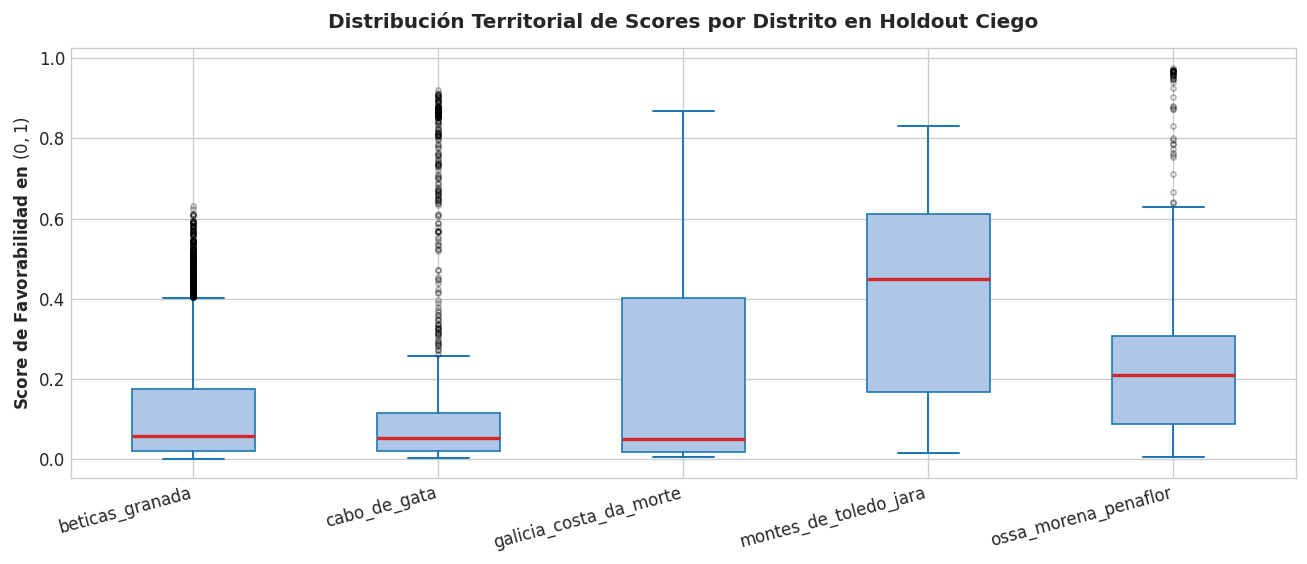

,district_id,total_cells,p_cells,n_deposits,deposits_list,score_mean,deposits_recovered_at_01,deposits_recovered_at_05,deposits_recovered_at_10
0,dist_beticas_granada,4975,1,1,dep_california_granadina_darro,0.122147,0,0,0
1,dist_cabo_de_gata,1681,4,2,dep_rodalquilar_cinto; dep_rodalquilar_santa_j...,0.143484,1,1,1
2,dist_galicia_costa_da_morte,2196,6,2,dep_corcoesto; dep_santa_comba_zas,0.214842,0,0,0
3,dist_montes_de_toledo_jara,2366,4,1,dep_la_oriental_la_jara,0.405061,0,0,1
4,dist_ossa_morena_penaflor,2323,4,2,dep_la_almenara_penaflor; dep_navalmedio_penaflor,0.225366,0,0,0


In [6]:
# Cargar tabla por distrito
df_districts = pd.read_csv(RUN_DIR_G / "metrics" / "holdout_by_district.csv")

# Distribución de scores por distrito (Boxplot con las 13.541 celdas)
fig, ax = plt.subplots(figsize=(11, 4.8))
dist_ids = df_districts['district_id'].tolist()
data_by_dist = [df_preds.loc[df_preds['district_id'] == d, 'score'].values for d in dist_ids]

bplot = ax.boxplot(data_by_dist, tick_labels=[d.replace('dist_', '') for d in dist_ids], patch_artist=True,
                    boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
                    medianprops=dict(color='#d62728', lw=2),
                    whiskerprops=dict(color='#1f77b4', lw=1.2),
                    capprops=dict(color='#1f77b4', lw=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))

ax.set_ylabel('Score de Favorabilidad en $(0, 1)$', fontweight='bold')
ax.set_title('Distribución Territorial de Scores por Distrito en Holdout Ciego', fontweight='bold', pad=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

df_districts[['district_id', 'total_cells', 'p_cells', 'n_deposits', 'deposits_list', 'score_mean', 'deposits_recovered_at_01', 'deposits_recovered_at_05', 'deposits_recovered_at_10']]


## 6. Análisis de Incertidumbre Bootstrap a Nivel de Depósito (N = 8)

Dado que el conjunto de test ciego comprende únicamente **8 depósitos auríferos**, cualquier métrica de recuperación se encuentra sujeta a una **fuerte granularidad discreta**: cada depósito recuperado representa un salto exacto del $1/8 = 12.5\%$ en la tasa global.

Para estimar rigurosamente la incertidumbre muestral sin suposiciones paramétricas asintóticas, se ejecutó un procedimiento **Bootstrap con 2.000 replicaciones** remuestreando con reemplazo a nivel de `deposit_id`.


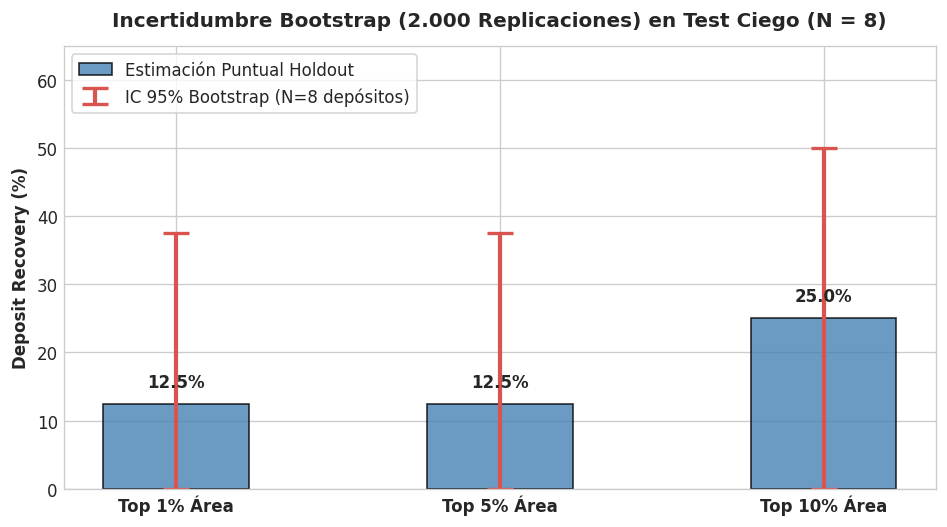

,Umbral,Estimación Puntual,Media Bootstrap,Desv. Estándar Bootstrap,Rango IC 95%
0,Top 1% Área,12.50%,12.38%,11.43%,"[0.0%, 37.5%]"
1,Top 5% Área,12.50%,12.38%,11.43%,"[0.0%, 37.5%]"
2,Top 10% Área,25.00%,24.85%,14.96%,"[0.0%, 50.0%]"


In [7]:
# Cargar bootstrap de incertidumbre
with open(RUN_DIR_G / "metrics" / "bootstrap_deposit_uncertainty.json", "r", encoding="utf-8") as f:
    boot_data = json.load(f)

boot_rows = []
for k in ["01", "05", "10"]:
    key = f"recovery_at_{k}"
    entry = boot_data[key]
    boot_rows.append({
        "Umbral": f"Top {int(k)}% Área",
        "Estimación Puntual": f"{entry['point_estimate'] * 100:.2f}%",
        "Media Bootstrap": f"{entry['bootstrap_mean'] * 100:.2f}%",
        "Desv. Estándar Bootstrap": f"{entry['bootstrap_std'] * 100:.2f}%",
        "IC 95% Percentil (Low)": f"{entry['ci_95_percentile_low'] * 100:.2f}%",
        "IC 95% Percentil (High)": f"{entry['ci_95_percentile_high'] * 100:.2f}%",
        "Rango IC 95%": f"[{entry['ci_95_percentile_low'] * 100:.1f}%, {entry['ci_95_percentile_high'] * 100:.1f}%]"
    })

df_boot = pd.DataFrame(boot_rows)

# Visualización de barras con error
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(len(boot_rows))
point_vals = [boot_data[f"recovery_at_{k}"]['point_estimate'] * 100 for k in ["01", "05", "10"]]
err_low = [point_vals[i] - boot_data[f"recovery_at_{k}"]['ci_95_percentile_low'] * 100 for i, k in enumerate(["01", "05", "10"])]
err_high = [boot_data[f"recovery_at_{k}"]['ci_95_percentile_high'] * 100 - point_vals[i] for i, k in enumerate(["01", "05", "10"])]

ax.bar(x_pos, point_vals, color='#4682b4', alpha=0.8, edgecolor='black', width=0.45, label='Estimación Puntual Holdout')
ax.errorbar(x_pos, point_vals, yerr=[err_low, err_high], fmt='none', ecolor='#d9534f', elinewidth=2.5, capsize=8, capthick=2, label='IC 95% Bootstrap (N=8 depósitos)')

ax.set_xticks(x_pos)
ax.set_xticklabels([b['Umbral'] for b in boot_rows], fontweight='bold')
ax.set_ylabel('Deposit Recovery (%)', fontweight='bold')
ax.set_ylim(0, 65)
ax.set_title('Incertidumbre Bootstrap (2.000 Replicaciones) en Test Ciego (N = 8)', fontweight='bold', pad=12)
ax.legend(loc='upper left', frameon=True)

for i, v in enumerate(point_vals):
    ax.text(i, v + 2.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

df_boot[['Umbral', 'Estimación Puntual', 'Media Bootstrap', 'Desv. Estándar Bootstrap', 'Rango IC 95%']]


## 7. Comparación Desarrollo (Nested CV OOF) vs Holdout Ciego: Brecha de Transferencia

Al comparar las estimaciones fuera de pliegue (*out-of-fold*, OOF) obtenidas durante la validación cruzada anidada en el conjunto de desarrollo con los resultados del holdout ciego, se observa una **brecha de transferencia (*transfer gap*)**:
- La recuperación a 1% se mantiene comparable ($14.4\%$ en OOF vs $12.5\%$ en holdout; $\Delta = -1.9\%$).
- La recuperación a 5% y 10% exhibe una reducción significativa (de $43.9\%$ a $12.5\%$ en top 5%, y de $52.8\%$ a $25.0\%$ en top 10%).
- Esta diferencia refleja la penalización en distritos ciegos cuyas asociaciones metalogenéticas locales (como la mineralización en Galicia) difieren sustancialmente del promedio capturado en el conjunto de desarrollo, confirmando la necesidad de reportar intervalos de transferencia territorial realistas.


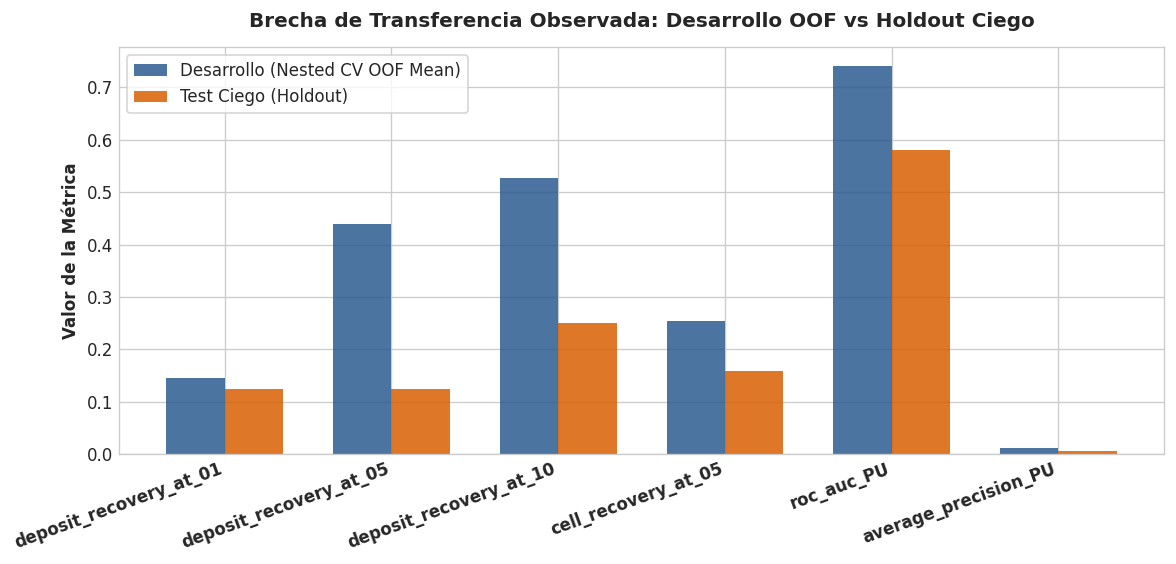

,metric,nested_spatial_cv_oof_mean,nested_spatial_cv_oof_std,development_cv_internal_mean,holdout_blind_evaluation,delta_vs_nested_oof,delta_vs_dev_cv
0,deposit_recovery_at_01,0.144444,0.144871,0.090175,0.125000,-0.019444,0.034825
1,deposit_recovery_at_05,0.438889,0.180449,0.320585,0.125000,-0.313889,-0.195585
2,deposit_recovery_at_10,0.527778,0.238953,0.468670,0.250000,-0.277778,-0.218670
3,cell_recovery_at_05,0.254722,0.099725,0.217080,0.157895,-0.096827,-0.059186
4,roc_auc_PU,0.740182,0.205424,0.735681,0.580660,-0.159522,-0.155021
5,average_precision_PU,0.011861,0.008258,NaN,0.006524,-0.005338,NaN


In [8]:
df_comp = pd.read_csv(RUN_DIR_G / "metrics" / "development_vs_holdout_comparison.csv")

# Gráfico comparativo de barras
fig, ax = plt.subplots(figsize=(10, 4.8))
metrics_plot = df_comp['metric'].tolist()
x = np.arange(len(metrics_plot))
width = 0.35

rects1 = ax.bar(x - width/2, df_comp['nested_spatial_cv_oof_mean'], width, label='Desarrollo (Nested CV OOF Mean)', color='#2b5c8f', alpha=0.85)
rects2 = ax.bar(x + width/2, df_comp['holdout_blind_evaluation'], width, label='Test Ciego (Holdout)', color='#d95f02', alpha=0.85)

ax.set_ylabel('Valor de la Métrica', fontweight='bold')
ax.set_title('Brecha de Transferencia Observada: Desarrollo OOF vs Holdout Ciego', fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, rotation=20, ha='right', fontweight='bold')
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

df_comp


## 8. Conclusiones y Guardarraíles de la Fase G

1. **Protocolo Sellado:** La evaluación ciega se completó rigurosamente sin alteración de hiperparámetros, umbrales ni variables tras la observación del holdout.
2. **Capacidad Predictiva:** El modelo es capaz de priorizar yacimientos de clase mundial en dominios no vistos (percentil 99.65% en Rodalquilar Cinto, 93.07% en La Oriental), mientras que revela limitaciones en dominios metamórficos orogénicos como Galicia.
3. **Guardarraíl Terminológico:** Los scores calculados representan **favorabilidad relativa** (*prospectivity score* en $(0, 1)$), no probabilidades absolutas de existencia de yacimientos comerciales.
